# Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading the Dataset

In [4]:
# Load Dataset
df = pd.read_csv('spam.csv', encoding='latin-1')


# Exploratory Data Analysis

  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None
label      0
message    0
dtype: int64
403
label
ham     4516
spam     653
Name: count, dtype: int64


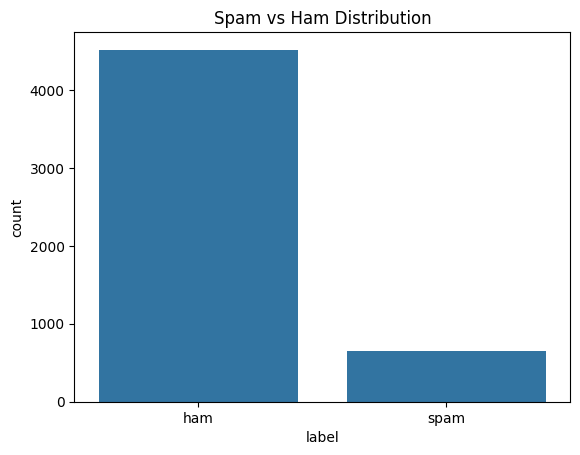

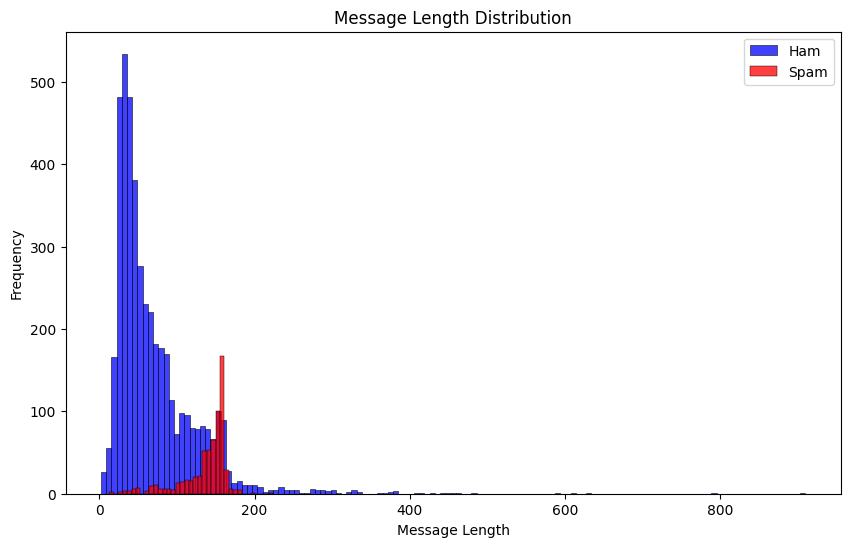

In [5]:
# Keep Required Columns
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

# Display Dataset
print(df.head())

# Dataset Information
print(df.info())

# Null Values
print(df.isnull().sum())

# Duplicate Values
print(df.duplicated().sum())

# Remove Duplicates
df = df.drop_duplicates(keep='first')

# Class Distribution
print(df['label'].value_counts())

# Spam vs Ham Countplot
sns.countplot(x=df['label'])
plt.title('Spam vs Ham Distribution')
plt.show()

# Message Length Analysis
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(10,6))

sns.histplot(
    df[df['label']=='ham']['message_length'],
    color='blue',
    label='Ham'
)

sns.histplot(
    df[df['label']=='spam']['message_length'],
    color='red',
    label='Spam'
)

plt.legend()
plt.title('Message Length Distribution')
plt.xlabel('Message Length')
plt.ylabel('Frequency')

plt.show()

# Text Preprocessing

In [6]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

# Download Resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# Convert Labels
df['label'] = df['label'].map({'ham':0, 'spam':1})

# Initialize Stemmer
ps = PorterStemmer()

# Text Cleaning Function
def transform_text(text):

    text = text.lower()

    text = nltk.word_tokenize(text)

    y = []

    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)

# Apply Cleaning
df['transformed_message'] = df['message'].apply(transform_text)

# Display Processed Data
print(df.head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   label                                            message  message_length  \
0      0  Go until jurong point, crazy.. Available only ...             111   
1      0                      Ok lar... Joking wif u oni...              29   
2      1  Free entry in 2 a wkly comp to win FA Cup fina...             155   
3      0  U dun say so early hor... U c already then say...              49   
4      0  Nah I don't think he goes to usf, he lives aro...              61   

                                 transformed_message  
0  go jurong point crazi avail bugi n great world...  
1                              ok lar joke wif u oni  
2  free entri 2 wkli comp win fa cup final tkt 21...  
3                u dun say earli hor u c alreadi say  
4               nah think goe usf live around though  


# FEATURE ENGINEERING

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_message']).toarray()

y = df['label'].values

# Feature Shape
print(X.shape)

(5169, 3000)


# Model Training

In [8]:
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score

# Train Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Initialize Models
nb_model = MultinomialNB()

lr_model = LogisticRegression(max_iter=1000)

svm_model = SVC(kernel='linear')

rf_model = RandomForestClassifier(n_estimators=100)

# Train Models
nb_model.fit(X_train, y_train)

lr_model.fit(X_train, y_train)

svm_model.fit(X_train, y_train)

rf_model.fit(X_train, y_train)

# Predictions
nb_pred = nb_model.predict(X_test)

lr_pred = lr_model.predict(X_test)

svm_pred = svm_model.predict(X_test)

rf_pred = rf_model.predict(X_test)

# Accuracy Scores
print("Naive Bayes Accuracy:",
      accuracy_score(y_test, nb_pred))

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, lr_pred))

print("SVM Accuracy:",
      accuracy_score(y_test, svm_pred))

print("Random Forest Accuracy:",
      accuracy_score(y_test, rf_pred))

Naive Bayes Accuracy: 0.9729206963249516
Logistic Regression Accuracy: 0.9584139264990329
SVM Accuracy: 0.9825918762088974
Random Forest Accuracy: 0.971953578336557


# Model Evaluation

----- Naive Bayes -----
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       889
           1       0.99      0.81      0.89       145

    accuracy                           0.97      1034
   macro avg       0.98      0.91      0.94      1034
weighted avg       0.97      0.97      0.97      1034

----- Logistic Regression -----
              precision    recall  f1-score   support

           0       0.96      0.99      0.98       889
           1       0.95      0.74      0.83       145

    accuracy                           0.96      1034
   macro avg       0.95      0.87      0.91      1034
weighted avg       0.96      0.96      0.96      1034

----- SVM -----
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.98      0.89      0.93       145

    accuracy                           0.98      1034
   macro avg       0.98      0.94      0.96      1034
we

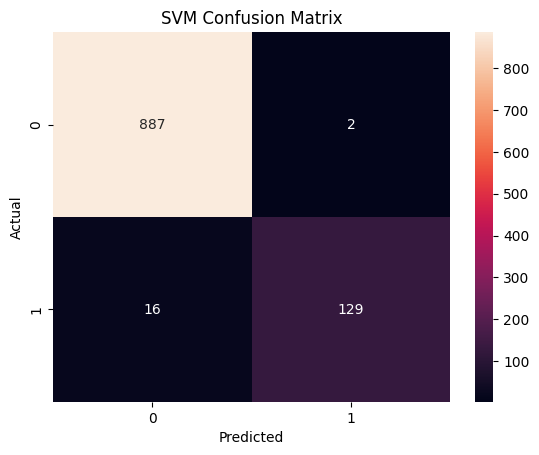

In [9]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Classification Reports

print("----- Naive Bayes -----")
print(classification_report(y_test, nb_pred))

print("----- Logistic Regression -----")
print(classification_report(y_test, lr_pred))

print("----- SVM -----")
print(classification_report(y_test, svm_pred))

print("----- Random Forest -----")
print(classification_report(y_test, rf_pred))

# Confusion Matrix for SVM

cm = confusion_matrix(y_test, svm_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('SVM Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

# Model Comparison

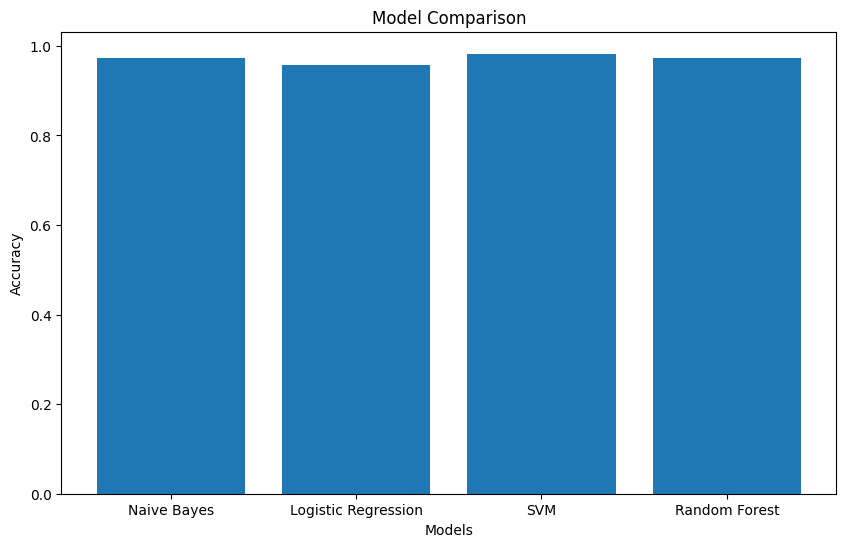

In [10]:
models = [
    'Naive Bayes',
    'Logistic Regression',
    'SVM',
    'Random Forest'
]

accuracies = [
    accuracy_score(y_test, nb_pred),
    accuracy_score(y_test, lr_pred),
    accuracy_score(y_test, svm_pred),
    accuracy_score(y_test, rf_pred)
]

plt.figure(figsize=(10,6))

plt.bar(models, accuracies)

plt.title('Model Comparison')

plt.xlabel('Models')

plt.ylabel('Accuracy')

plt.show()

# Save Models

In [11]:
import pickle

pickle.dump(tfidf, open('vectorizer.pkl', 'wb'))

pickle.dump(nb_model, open('naive_bayes_model.pkl', 'wb'))

pickle.dump(lr_model, open('logistic_regression_model.pkl', 'wb'))

pickle.dump(svm_model, open('svm_model.pkl', 'wb'))

pickle.dump(rf_model, open('random_forest_model.pkl', 'wb'))

print("Models Saved Successfully")

Models Saved Successfully


In [13]:
sample = ["URGENT! You have won a FREE lottery claim now"]

sample = tfidf.transform(sample).toarray()

print(svm_model.predict(sample))

[1]
